#### Exploratory Analysis – National and Local Trend

##### Questions addressed

1. How have alcohol-related hospitalisation rates changed over time?
2. How does Dundee compare with the Scottish average?
3. Which conditions contribute most to the burden?

In [0]:
#Import python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [0]:
# Project paths

DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = Path('../figures')


#Constants
DUNDEE = 'Dundee City'
SCOTLAND = 'Scotland'

In [0]:
#load clean, analysis ready, ARHS dataset by council area

if Path('/Volumes').exists():
    PROCESSED_DIR = Path('/Volumes/group_project_wfs2025/default/arhs')
    FIGURES_DIR = PROCESSED_DIR
else:
    PROCESSED_DIR = Path('../data/processed')
    FIGURES_DIR = Path('../figures')

arhs_council_df = pd.read_csv(PROCESSED_DIR / 'ARHS_byCouncilArea_clean.csv')

arhs_council_df


,_id,condition,smr_type_code,financial_year_label,council_code,easr_stays,easr_patients,easr_new_patients,number_of_stays,number_of_patients,number_of_new_patients,average_number_of_stays_per_patient,financial_year,council_area,smr_type
0,1,All alcohol conditions,SMR01,1981/82,S92000003,156.6,138.3,0.0,7254,6435,0,1.1,1981,Scotland,Non-psychiatric
1,2,All alcohol conditions,SMR01,1982/83,S92000003,154.5,135.9,0.0,7149,6303,0,1.1,1982,Scotland,Non-psychiatric
2,3,All alcohol conditions,SMR01,1983/84,S92000003,170.0,145.8,0.0,7845,6762,0,1.2,1983,Scotland,Non-psychiatric
3,4,All alcohol conditions,SMR01,1984/85,S92000003,184.4,158.3,0.0,8577,7413,0,1.2,1984,Scotland,Non-psychiatric
4,5,All alcohol conditions,SMR01,1985/86,S92000003,207.0,176.9,0.0,9534,8190,0,1.2,1985,Scotland,Non-psychiatric
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,20100,Alcohol-induced pancreatitis,SMR01,2019/20,S92000003,14.5,10.5,3.4,771,558,180,1.4,2019,Scotland,Non-psychiatric
20100,20101,Alcohol-induced pancreatitis,SMR01,2020/21,S92000003,13.0,9.8,3.2,684,519,171,1.3,2020,Scotland,Non-psychiatric
20101,20102,Alcohol-induced pancreatitis,SMR01,2021/22,S92000003,13.5,9.9,3.2,708,522,171,1.4,2021,Scotland,Non-psychiatric
20102,20103,Alcohol-induced pancreatitis,SMR01,2022/23,S92000003,10.8,8.5,2.9,567,447,150,1.3,2022,Scotland,Non-psychiatric


      financial_year  easr_patients financial_year_label
1798            1997          522.3              1997/98
1799            1998          530.4              1998/99
1800            1999          553.2              1999/00
1801            2000          536.9              2000/01
1802            2001          560.5              2001/02
1803            2002          576.2              2002/03
1804            2003          570.6              2003/04
1805            2004          597.8              2004/05
1806            2005          583.5              2005/06
1807            2006          595.9              2006/07
1808            2007          614.1              2007/08
1809            2008          599.9              2008/09
1810            2009          560.1              2009/10
1811            2010          544.3              2010/11
1812            2011          533.4              2011/12
1813            2012          499.7              2012/13
1814            2013          5

/home/spark-155eff28-b8f8-4683-8ac3-3b/.ipykernel/2039/command-1038540920161319-3352330234:31: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


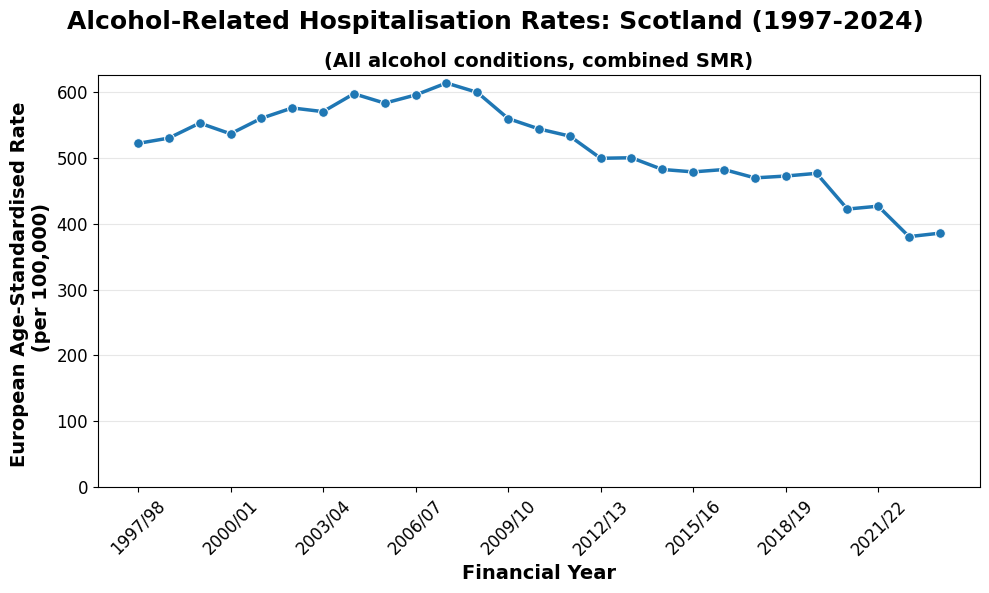

In [0]:
#Figure 1 — National burden of alcohol-related hospitalisations over time
#Scotland only, Combined SMR type, All alcohol conditions
#Line plot - FinancialYear vs EASRPatients

#Filter dataset - Scotland only, Combined SMR, All alcohol conditions
scotland_combined_all_alcohol = arhs_council_df[(arhs_council_df['council_area'] == SCOTLAND)
                                                & (arhs_council_df['smr_type'] == 'Combined')
                                                & (arhs_council_df['condition'] == 'All alcohol conditions')]

print(scotland_combined_all_alcohol[['financial_year', 'easr_patients', 'financial_year_label']])

scotland_combined_all_alcohol_ts = (
    scotland_combined_all_alcohol
    .groupby(['financial_year', 'financial_year_label'])
    .agg({'easr_patients' : 'mean'})
    .reset_index()
)

print(scotland_combined_all_alcohol_ts)

#Add new column - Region = Scotland
scotland_combined_all_alcohol_ts['Region'] = SCOTLAND

print(scotland_combined_all_alcohol_ts)

#Lineplot -  FinancialYear vs EASRPatients
fig, ax = plt.subplots(figsize=(10, 6))

custom_palette = sns.color_palette(['#1f77b4'])

sns.lineplot(
    data = scotland_combined_all_alcohol_ts,
    x = 'financial_year',
    y = 'easr_patients',
    palette = custom_palette,
    marker = 'o',
    ms = 7,
    linewidth = 2.5
)

plt.suptitle(
    'Alcohol-Related Hospitalisation Rates: Scotland (1997-2024)',
    fontsize = 18,
    weight = 'bold'
)

ax.set_title(
    '(All alcohol conditions, combined SMR)',
    weight = 'bold',
    size = 14
)

ax.set_xlabel(
    'Financial Year',
    weight = 'bold',
    size = 14
)

ax.set_ylabel(
    'European Age-Standardised Rate \n (per 100,000)',
    weight = 'bold',
    size = 14
)

ax.set_xticks(
    scotland_combined_all_alcohol_ts['financial_year'][::3]
)

ax.set_xticklabels(
    scotland_combined_all_alcohol_ts['financial_year_label'][::3],
    rotation = 45,
    size = 12
)

plt.yticks(size = 12)

ax.set_ylim(ymin=0)

ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(FIGURES_DIR / 'ARHS_Figure1_national_trend.jpg', dpi = 300, bbox_inches='tight')

plt.show()




      financial_year  easr_patients financial_year_label
1837            1997          548.3              1997/98
1869            1998          575.8              1998/99
1901            1999          647.0              1999/00
1933            2000          631.1              2000/01
1965            2001          596.6              2001/02
1997            2002          578.6              2002/03
2029            2003          623.3              2003/04
2061            2004          591.1              2004/05
2093            2005          614.6              2005/06
2125            2006          580.7              2006/07
2157            2007          545.7              2007/08
2189            2008          640.8              2008/09
2221            2009          638.7              2009/10
2253            2010          661.9              2010/11
2285            2011          541.1              2011/12
2317            2012          530.3              2012/13
2349            2013          5

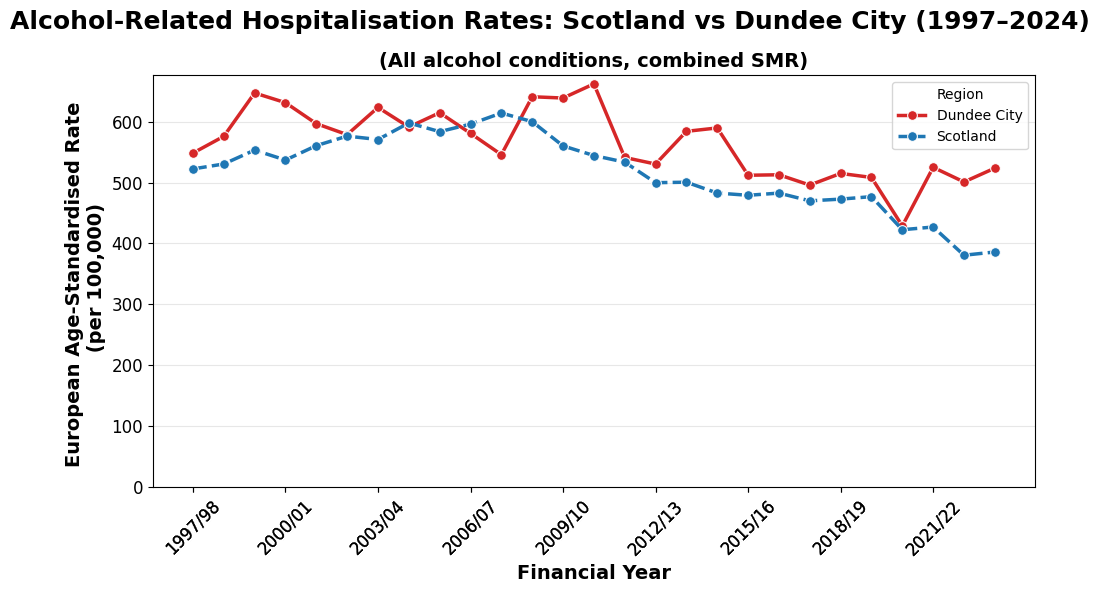

In [0]:
#Figure 2 — Dundee vs Scotland: alcohol-related hospitalisation rates over time
#Dundee City vs Scotland, Combined SMR, All alcohol conditions
#Dual-line time series - FinancialYear vs EASRPatients

#Filter dataset - Dundee only, Combined SMR, All alcohol conditions
dundee_combined_all_alcohol = arhs_council_df[(arhs_council_df['council_area'] == DUNDEE)
                                                & (arhs_council_df['smr_type'] == 'Combined')
                                                & (arhs_council_df['condition'] == 'All alcohol conditions')]

print(dundee_combined_all_alcohol[['financial_year', 'easr_patients', 'financial_year_label']])

dundee_combined_all_alcohol_ts = (
    dundee_combined_all_alcohol
    .groupby(['financial_year', 'financial_year_label'])
    .agg({'easr_patients' : 'mean'})
    .reset_index()
)

print(dundee_combined_all_alcohol_ts)

#Add new column - Region = Dundee
dundee_combined_all_alcohol_ts['Region'] = DUNDEE

print(dundee_combined_all_alcohol_ts)

#Concatenate Dundee and Scotland datasets
dundee_scotland_ts = (
    pd.concat([dundee_combined_all_alcohol_ts, scotland_combined_all_alcohol_ts],
              axis = 0,
              ignore_index = True
    )
)

print(dundee_scotland_ts)

#Plot
fig, ax = plt.subplots(figsize=(10, 6))

custom_palette = sns.color_palette(['#d62728', '#1f77b4'])

sns.lineplot(
    data = dundee_scotland_ts,
    x = 'financial_year',
    y = 'easr_patients',
    hue = 'Region',
    style='Region',
    palette = custom_palette,
    marker = 'o',
    ms = 7,
    linewidth = 2.5
)

plt.suptitle(
    'Alcohol-Related Hospitalisation Rates: Scotland vs Dundee City (1997–2024)',
    fontsize = 18,
    weight = 'bold'
)

ax.set_title(
    '(All alcohol conditions, combined SMR)',
    weight = 'bold',
    size = 14
)

ax.legend(
    title = 'Region'
)

ax.set_xlabel(
    'Financial Year',
    weight = 'bold',
    size = 14
)

ax.set_ylabel(
    'European Age-Standardised Rate \n (per 100,000)',
    weight = 'bold',
    size = 14
)

ax.set_xticks(
    dundee_scotland_ts['financial_year'][::3]
)

ax.set_xticklabels(
    dundee_scotland_ts['financial_year_label'][::3],
    rotation = 45,
    size = 12
)

plt.yticks(size = 12)
ax.set_ylim(ymin=0)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ARHS_Figure2_dundee_vs_scotland.jpg', dpi = 300, bbox_inches='tight')
plt.show()

      financial_year  easr_patients financial_year_label
7264            1997          404.6              1997/98
7296            1998          450.5              1998/99
7328            1999          522.4              1999/00
7360            2000          485.7              2000/01
7392            2001          473.2              2001/02
7424            2002          457.4              2002/03
7456            2003          458.4              2003/04
7488            2004          460.6              2004/05
7520            2005          439.3              2005/06
7552            2006          402.0              2006/07
7584            2007          423.2              2007/08
7616            2008          469.3              2008/09
7648            2009          508.2              2009/10
7680            2010          533.8              2010/11
7712            2011          452.0              2011/12
7744            2012          446.7              2012/13
7776            2013          4

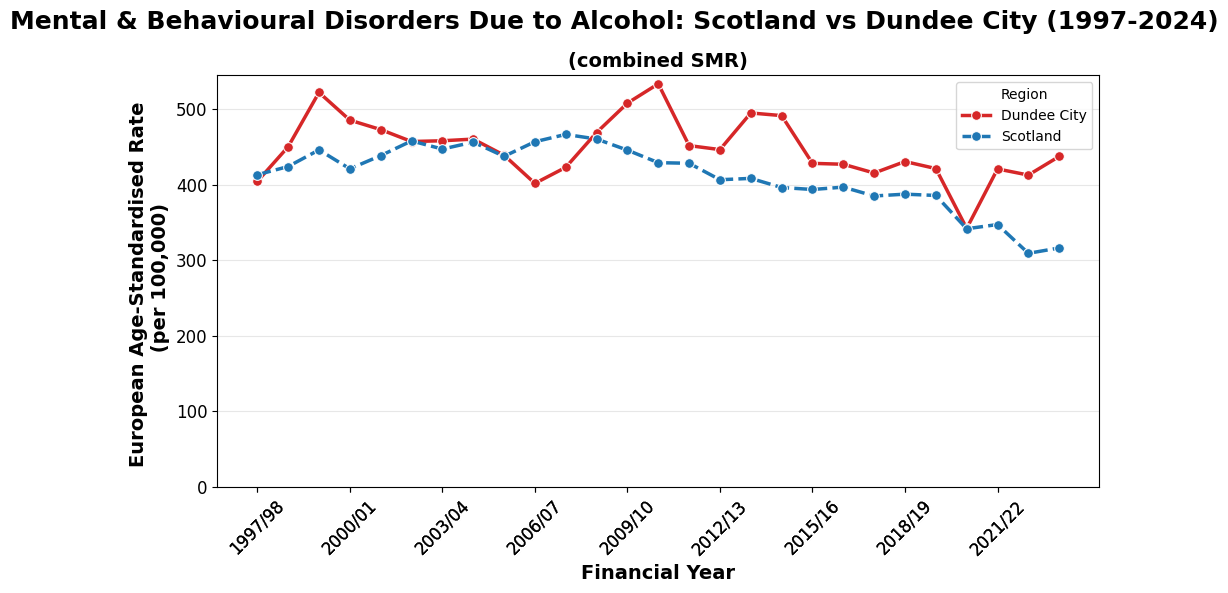

In [0]:
#Figure 3 — Dundee vs Scotland: alcohol-related mental & behavioural disorders
#Condition: “Mental & behavioural disorders due to use of alcohol: All”, SMR combined
#Line plot - FinancialYear vs EASRPatients

#Filter dataset - Dundee only, Combined SMR, Mental & behavioural disorders due to use of alcohol: All
dundee_combined_mh_all = arhs_council_df[(arhs_council_df['council_area'] == DUNDEE)
                                                & (arhs_council_df['smr_type'] == 'Combined')
                                                & (arhs_council_df['condition'] == 'Mental & behavioural disorders due to use of alcohol: All')]

print(dundee_combined_mh_all[['financial_year', 'easr_patients', 'financial_year_label']])

dundee_combined_mh_all_ts = (
    dundee_combined_mh_all
    .groupby(['financial_year', 'financial_year_label'])
    .agg({'easr_patients' : 'mean'})
    .reset_index()
)

print(dundee_combined_mh_all_ts)

#Add new column - Region = Dundee
dundee_combined_mh_all_ts['Region'] = DUNDEE

print(dundee_combined_mh_all_ts)

#Filter dataset - Scotland only, Combined SMR, Mental & behavioural disorders due to use of alcohol: All
scotland_combined_mh_all = arhs_council_df[(arhs_council_df['council_area'] == SCOTLAND)
                                                & (arhs_council_df['smr_type'] == 'Combined')
                                                & (arhs_council_df['condition'] == 'Mental & behavioural disorders due to use of alcohol: All')]

print(scotland_combined_mh_all[['financial_year', 'easr_patients', 'financial_year_label']])

scotland_combined_mh_all_ts = (
    scotland_combined_mh_all
    .groupby(['financial_year', 'financial_year_label'])
    .agg({'easr_patients' : 'mean'})
    .reset_index()
)

print(scotland_combined_mh_all_ts)

#Add new column - Region = Dundee
scotland_combined_mh_all_ts['Region'] = SCOTLAND

print(scotland_combined_mh_all_ts)

#Concatenate Dundee and Scotland datasets
dundee_scotland_mh_all_ts = (
    pd.concat([dundee_combined_mh_all_ts, scotland_combined_mh_all_ts],
              axis = 0,
              ignore_index = True
    )
)

print(dundee_scotland_mh_all_ts)

#Plot
fig, ax = plt.subplots(figsize=(10, 6))

custom_palette = sns.color_palette(['#d62728', '#1f77b4'])

sns.lineplot(
    data = dundee_scotland_mh_all_ts,
    x = 'financial_year',
    y = 'easr_patients',
    hue = 'Region',
    style='Region',
    palette = custom_palette,
    marker = 'o',
    ms = 7,
    linewidth = 2.5
)

plt.suptitle(
    'Mental & Behavioural Disorders Due to Alcohol: Scotland vs Dundee City (1997-2024)',
    fontsize = 18,
    weight = 'bold'
)

ax.set_title(
    '(combined SMR)',
    fontsize = 14,
    weight = 'bold'
)

ax.legend(
    title = 'Region'
)

ax.set_xlabel(
    'Financial Year',
    weight = 'bold',
    size = 14
)

ax.set_ylabel(
    'European Age-Standardised Rate \n (per 100,000)',
    weight = 'bold',
    size = 14
)

ax.set_xticks(
    dundee_scotland_ts['financial_year'][::3]
)

ax.set_xticklabels(
    dundee_scotland_ts['financial_year_label'][::3],
    rotation = 45,
    size = 12
)

plt.yticks(size = 12)
ax.set_ylim(ymin=0)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ARHS_Figure3_mh_conditions.jpg', dpi = 300, bbox_inches='tight')
plt.show()

       financial_year  ...                     condition
1798             1997  ...        All alcohol conditions
1799             1998  ...        All alcohol conditions
1800             1999  ...        All alcohol conditions
1801             2000  ...        All alcohol conditions
1802             2001  ...        All alcohol conditions
...               ...  ...                           ...
19127            2019  ...  Alcohol Related Brain Damage
19128            2020  ...  Alcohol Related Brain Damage
19129            2021  ...  Alcohol Related Brain Damage
19130            2022  ...  Alcohol Related Brain Damage
19131            2023  ...  Alcohol Related Brain Damage

[270 rows x 4 columns]
                                           condition  easr_patients
0                       Alcohol Related Brain Damage      14.588889
1                             All alcohol conditions     516.996296
2                           M&B - Acute Intoxication     147.622222
3                  M

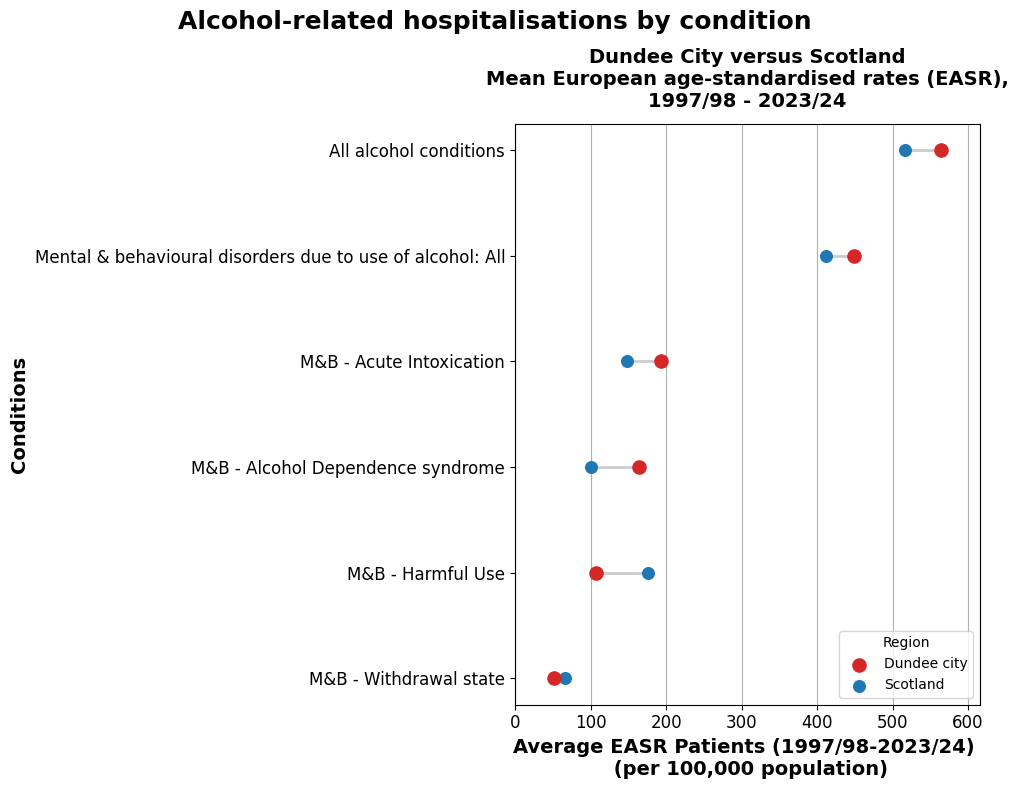

In [0]:
#Figure 4 — Condition-specific burden comparison (Dundee vs Scotland)
#Mean EASRPatients per condition - across all years
#Dundee vs Scotland - dumbbell plot

#Filter dataset - Scotland only, Combined SMR
scotland_combined_condition = (
    arhs_council_df[(arhs_council_df['council_area'] == SCOTLAND)
                    & (arhs_council_df['smr_type'] == 'Combined')]
)

print(scotland_combined_condition[['financial_year', 'easr_patients', 'financial_year_label', 'condition']])

#Mean of EASRPatients per condition - across all years
mean_conditions_scotland = (
    scotland_combined_condition
    .groupby(['condition'])
    .agg({'easr_patients' : 'mean'})
    .reset_index()
)

print(mean_conditions_scotland)

#Filter dataset - Dundee only, Combined SMR
dundee_combined_condition = (
    arhs_council_df[(arhs_council_df['council_area'] == DUNDEE)
                    & (arhs_council_df['smr_type'] == 'Combined')]
)

print(dundee_combined_condition[['financial_year', 'easr_patients', 'financial_year_label', 'condition']])

#Mean of EASRPatients per condition - across all years

mean_conditions_dundee = (
    dundee_combined_condition
    .groupby(['condition'])
    .agg({'easr_patients' : 'mean'})
    .reset_index()
)

print(mean_conditions_dundee)

#Merge datasets - Dundee and Scotland mean on Condition
mean_conditions_dundee_scotland = (
    pd.merge(mean_conditions_scotland, mean_conditions_dundee,
             on = 'condition',
             how = 'left',
             suffixes = ('_Scotland', '_Dundee')
    )
)

mean_conditions_dundee_scotland = (
    mean_conditions_dundee_scotland
    .sort_values('easr_patients_Dundee', ascending=True)
    .reset_index(drop = True)
)

print(mean_conditions_dundee_scotland)

#Check Null values
print(
    mean_conditions_dundee_scotland
    .isnull()
    .sum()
)

#Drop records with null values
mean_conditions_dundee_scotland = (
    mean_conditions_dundee_scotland
    .dropna()
)

print(mean_conditions_dundee_scotland)

#Dumbbell plot - Dundee vs Scotland
fig, ax = plt.subplots(figsize = (10,8))

#horizontal lines
my_range2 = (
    range(mean_conditions_dundee_scotland['condition']
          .nunique()
    )
)

print(my_range2)

ax.hlines(
    y = my_range2,
    xmin = mean_conditions_dundee_scotland['easr_patients_Dundee'],
    xmax = mean_conditions_dundee_scotland['easr_patients_Scotland'],
    color = 'grey',
    linestyle = 'solid',
    linewidth = 2,
    alpha = 0.4
)

#points
ax.scatter(
    mean_conditions_dundee_scotland['easr_patients_Dundee'],
    my_range2,
    zorder = 3, 
    color = '#d62728',
    s = 90,
    label = 'Dundee city'
)

ax.scatter(
    mean_conditions_dundee_scotland['easr_patients_Scotland'],
    my_range2,
    zorder = 2,
    color = '#1f77b4',
    s = 70,
    label = 'Scotland'
)

fig.suptitle(
    'Alcohol-related hospitalisations by condition',
    fontsize = 18,
    weight = 'bold',
    y = 0.98)

ax.set_title(
    'Dundee City versus Scotland\n'
    'Mean European age-standardised rates (EASR),\n'
    '1997/98 - 2023/24',
    fontsize = 14,
    pad = 12,
    weight = 'bold'
)

ax.set_xlabel(
    'Average EASR Patients (1997/98-2023/24) \n (per 100,000 population)',
    fontsize = 14,
    weight = 'bold'
)

ax.set_ylabel(
    'Conditions',
    fontsize = 14,
    weight = 'bold'
)

ax.set_yticks(my_range2)

ax.set_yticklabels(
    mean_conditions_dundee_scotland['condition'],
    size = 12
)

ax.tick_params(
    axis = 'x',
    labelsize = 12
)

plt.legend(
    title = "Region",
    loc = 'lower right'
)

plt.grid(True, axis="x")
ax.margins(x = 0.1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ARHS_Figure4_condition_dumbbell.jpg', dpi = 300, bbox_inches='tight')
plt.show()
